# Notes from AIMA20 Chapter 17 - Making Coomplex Decisions

## 17.1 Sequential Decision Problems

- a sequential decision problem for a fully observable, stochastic environment with a Markovian transition model and additive rewards is called a Markov decision process (MDP).
- Includes:
    1. set of states with iniital state $s_0$
    2. set of actions of each state
    3. transition model $P(s'|s,a)$
    4. reward function $R(s,a,s')$
- Using a negataive reward gives the agent an incentive to reach the goal state quickly -- environment is a stochastic generalization of search problems
    - Agent does not enjoy living in this environment and so it wants to leave as soon as possible
- **Methods for solving MDPs usually involve dynamic programming**

### Policy

- What does a solution to the problem loook like? No fixed sequene can solve it because the agent might end up in a state other than the goal
- **Solution must specify what the agent *should* do for *any* state that the agent might reach** --> called a **Policy**
- Policy is denoted by $\pi(s)$ - action recommended by the policy $\pi$ for state $s$
- No matte what the outcome of the action, the resulting state will be in the policy, and the agent will know what to do next

### Optimal Policy

- policy that yields highest expected utility
- denoted by $\pi*$
- quality of a policy is measured by the expected utility of the possible environment histories generated by that policy
- Often multiple optimal policies


# How the Policy Changes with the Living Reward \(R\)

## 1. What Is Being Optimized?

In this stochastic gridworld, the agent does **not** optimize guaranteed outcomes.  
It optimizes **expected total discounted reward**.

The optimal value function satisfies the Bellman optimality equation:

$$
V^*(s) = \max_a \sum_{s'} P(s' \mid s,a)\left[ r(s,a,s') + \gamma V^*(s') \right]
$$

The optimal policy is:

$$
\pi^*(s) = \arg\max_a \sum_{s'} P(s' \mid s,a)\left[ r(s,a,s') + \gamma V^*(s') \right]
$$

So for each action, the agent computes the **expected return**, not the certain return.

---

# Symbol Breakdown for the Bellman Optimality Equation

We are given:

$$
V^*(s) = \max_a \sum_{s'} P(s' \mid s,a)\left[ r(s,a,s') + \gamma V^*(s') \right]
$$

and

$$
\pi^*(s) = \arg\max_a \sum_{s'} P(s' \mid s,a)\left[ r(s,a,s') + \gamma V^*(s') \right]
$$

Below is what each symbol means.

---

## Core Objects

### $( s )$
A **state** in the environment.  
In gridworld, this is a grid cell like \( (3,1) \).

---

### $( a )$
An **action** the agent can take in state \( s \).  
Example: Up, Down, Left, Right.

---

### $( s' )$
A **next state**.  
The summation runs over all possible states the system could transition into after taking action \( a \) in state \( s \).

---

## Value Function

### $( V^*(s)) $
The **optimal value function**.

It represents:

$$
\text{Maximum expected total discounted reward starting from state } s
$$

The star \( * \) means it is **optimal**.

---

## Policy

### $( \pi^*(s)$
The **optimal policy**.

It returns:

$$
\text{The action that maximizes expected return in state } s
$$

The difference between the two equations:

- $( V^*(s) )$ gives the *value*
- $( \pi^*(s) )$ gives the *action*

---

## Transition Model

### $P(s' \mid s,a)$

The **transition probability**:

$$
P(s' \mid s,a) = \Pr(\text{next state is } s' \mid \text{current state } s, \text{action } a)
$$

This encodes stochasticity.

Example:
- 0.8 probability of moving intended direction
- 0.1 slip left
- 0.1 slip right

---

## Reward Function

### $r(s,a,s')$

The **immediate reward** received when:

- Starting in state \( s \),
- Taking action \( a \),
- Ending up in state \( s' \).

In the gridworld with living reward \(R\):

- Nonterminal step: \( r(s,a,s') = R \)
- Enter +1 terminal: reward = +1
- Enter -1 terminal: reward = -1

---

## Discount Factor

### $\gamma$

The **discount factor**, where:

$$
0 \le \gamma < 1
$$

It determines how much future rewards are worth relative to immediate rewards.

- $( \gamma \approx 0 )$: agent is short-sighted
- $( \gamma \approx 1 )$: agent cares strongly about future
- **Additivity was used implicitly in path cost functions in heuristic search algorithms**

---

## Operators

### $\sum_{s'}$

Sum over all possible next states.

This computes the **expected value** over stochastic outcomes.

---

### $\max_a$

Take the maximum over all possible actions.

This is what makes the value function **optimal**.

---

### $\arg\max_a$

Returns the **action** that achieves the maximum value.

- $\arg\max_a$ gives a number
- $\arg\max_a$ gives the action that produces that number

---

# Conceptual Summary

The equation says:

1. For each action \( a \),
2. Compute the expected immediate reward plus discounted future value,
3. Choose the action that gives the largest expected total.

Formally:

$$
\text{Optimal value} = \text{best expected return achievable from } s
$$

$$
\text{Optimal policy} = \text{action that achieves that best return}
$$


## 2. Role of the Living Reward \(R\)

Let \(R\) be the reward received for each non-terminal step.

If a trajectory lasts \(k\) steps before termination, the total contribution from living reward is:

$$
R + \gamma R + \gamma^2 R + \dots + \gamma^{k-1} R
$$

This is a geometric sum:

$$
R \sum_{t=0}^{k-1} \gamma^t
$$

The sign and magnitude of \(R\) determine whether long trajectories are desirable or harmful.

---

## 3. Why the Policy Changes with \(R\)

### Case 1: \(R \ll 0\) (Life is very painful)

Every additional step adds a large negative value.

Long trajectories are extremely costly:

$$
\text{More steps} \Rightarrow \text{larger negative accumulation}
$$

So the optimal strategy becomes:

> Terminate as quickly as possible.

Even entering the \(-1\) terminal may be preferable to enduring more negative living reward.

---

### Case 2: \(R < 0\) (Moderately negative)

Now there is still pressure to terminate quickly, but not at any cost.

The agent balances:

- Fewer steps (reducing negative accumulation)
- Avoiding the \(-1\) terminal
- Risk from stochastic transitions

Depending on position, it may:

- Head toward \(+1\) if reasonably reachable
- Dive into \(-1\) if the path to \(+1\) is too long or risky

---

### Case 3: \(R \approx 0\) (Slightly negative)

Now extra steps are not very costly.

The agent becomes risk-averse.

It prefers:

- Safer paths
- Avoiding states near \(-1\)
- Even taking inefficient detours

Here, minimizing risk dominates minimizing steps.

---

### Case 4: \(R > 0\) (Life is enjoyable)

Now each step adds positive reward.

Termination stops the reward stream.

So the agent prefers:

$$
\text{Avoid all terminal states}
$$

If it can loop forever, it accumulates reward indefinitely:

$$
\sum_{t=0}^{\infty} \gamma^t R = \frac{R}{1-\gamma}
$$

Thus, policies that avoid termination become optimal.

---

## 4. How Stochasticity Is Handled

Actions do not deterministically lead to one state. Instead:

$$
Q(s,a) =
\sum_{s'} P(s' \mid s,a)
\left[
r(s,a,s') + \gamma V^*(s')
\right]
$$

The agent evaluates **expected value**:

- It does not know the exact next state.
- It weighs all possible outcomes.
- It selects the action with maximum expected return.

---

## 5. Why Thresholds in \(R\) Exist

At certain values \(R = R_0\), two actions become equally good:

$$
Q_{R_0}(s,a_1) = Q_{R_0}(s,a_2)
$$

For:

- \(R < R_0\): one action is optimal  
- \(R > R_0\): the other action is optimal  

Thus the optimal policy is **piecewise constant in \(R\)**.

These thresholds mark where the tradeoff between:

- Step cost
- Risk
- Terminal reward
- Discounting

changes sign.

---

## 6. Core Insight

The agent does not “know” where it will land.

It chooses:

$$
\arg\max_a \mathbb{E}[\text{total discounted reward}]
$$

The living reward \(R\) changes whether:

- Long life is costly  
- Long life is tolerable  
- Long life is desirable  

That is why the optimal policy shifts as \(R\) varies.


# Utilities over Time

## Finite or infinite horizon
- finite horizon: fixed time N after which nothing matters
- With finite, an optimal action in a given state may depend on how much time is left
- **Policy that depends on time is called *nonstationary***
- With no fixed time limit, optimal action depends only on current state -- *stationary* policy
- *Infinite horizon does not necesarilly mean that all state sequences are infinite, just means no fixed deadline
    - There can be finite state sequences in infinite-horizon MDP w/ a terminal state
## Additive Rewards
- when $\gamma$ is exactly 1
- Additive discounting is the only form of utility on histories that satisfies stationarity (two histories should be preference ordered the same way as the histories) 
    - IOW - if you prefer one future to another starting tomorrow, then you should still prefer that future if it were to start today instead


# Optimal Policies
- a policy that is guaranteed to reach a terminal state is called a proper policy
- With proper policies, we can use $\gamma = 1$
- The existence of improper policies provides good reaon for using discounted rewards
- Some algorithms use average-reward -- used for comparing infinite sequences

Expected utility of following policy $\pi$ from state $s$:

$$
U^{\pi}(s) = \mathbb{E}\left[\sum_{t=0}^{\infty} \gamma^t \, R(S_t, \pi(S_t), S_{t+1})\right].
$$

- Where $\gamma$ discounts future rewards, and the expectation averages over stochastic transitions.
- Expectation E is with respect to the probability distribution over state sequences determined by $s$ and $\pi$
- Out of all the expected utilities, one will be higher than the others:

$$
\pi_s^{*} = \arg\max_{\pi} U^{\pi}(s).
$$

- With an infinite-horizon discounted MDP, there is one stationary optimal policy that is optimal from every state, not just one start state
    - used in MDP
    - Infinite horizon
    - discounted return
    - time-homegeneous dynamics/rewards (same rules each step)
- Cannot use in:
    - finite-horizon problems
    - objectives not discounted sum (max reward seen, average reward steps)
    - nonstationary environment (transisition/reward rules change with time)
- Why this matters
    - Can compute one value function and one policy
    - different start states give different $U(s)$ but same policy mapping $\pi^*$

# Understanding the Q-Function and Its Relation to the Bellman Equation

## What Is the Q-Function?

The action-value function is:

$$
Q(s,a)
$$

It represents:

> The expected total discounted reward if you start in state $s$, take action $a$, and then behave optimally afterward.

In simple terms:

- $V(s)$ asks: “How good is this state?”
- $Q(s,a)$ asks: “How good is taking this specific action from this state?”

---

## Bellman Equation for Optimal Q

The optimal Q-function satisfies:

$$
Q^*(s,a)
=
\sum_{s'} P(s' \mid s,a)
\left[
r(s,a,s')
+
\gamma \max_{a'} Q^*(s',a')
\right]
$$

This equation means:

1. From state $s$, take action $a$.
2. You may transition to different next states $s'$.
3. Each transition occurs with probability $P(s' \mid s,a)$.
4. You receive immediate reward $r(s,a,s')$.
5. From the next state $s'$, you act optimally, which is worth $\max_{a'} Q^*(s',a')$.
6. Future rewards are discounted by $\gamma$.
7. You compute the expected value over all possible $s'$.

---

## Relationship Between Q and V

The optimal state-value function is:

$$
V^*(s) = \max_a Q^*(s,a)
$$

So:

- $Q(s,a)$ evaluates each action.
- $V(s)$ selects the best action’s value. U(s) is same as V(s)

---

## Extracting the Optimal Policy

If you know $Q^*(s,a)$ for all states and actions, the optimal policy is:

$$
\pi^*(s) = \arg\max_a Q^*(s,a)
$$

This means:

> Choose the action with the highest expected long-term reward.

---

## Core Intuition

- $Q(s,a)$ = the long-term expected return of choosing action $a$ first.
- The Bellman equation defines how $Q$ must relate to future values.
- $V(s)$ is simply the best possible $Q(s,a)$ available at that state.

In summary:

1. The Bellman equation defines $Q^*$.
2. $Q^*$ determines $V^*$.
3. $V^*$ determines the optimal policy $\pi^*$. 

# Reward Shaping Theorem — Concise Summary

## Core Result

A reward modification preserves the optimal policy **if and only if** the shaping term has the form:

$F(s,s') = \gamma \Phi(s') - \Phi(s)$

The modified reward becomes:

$R'(s,a,s') = R(s,a,s') + \gamma \Phi(s') - \Phi(s)$

where:
- $\Phi(s)$ is a potential function over states,
- $\gamma$ is the discount factor.

---

## Why It Preserves Optimality

Over a trajectory, the shaping terms telescope:

$\sum_{t=0}^{\infty} \gamma^t \big(\gamma \Phi(s_{t+1}) - \Phi(s_t)\big)$

All intermediate terms cancel. Only boundary terms remain.

Thus:
- Every trajectory from the same start state shifts by the same constant.
- Relative action comparisons remain unchanged.
- The optimal policy is preserved.

---

## Special Case: Pure Potential Reward

If the original reward is zero everywhere and

$R(s,a,s') = \gamma \Phi(s') - \Phi(s)$

then all policies are optimal.

For $\gamma = 1$, the total return along any path from $A$ to $B$ collapses to:

$\Phi(B) - \Phi(A)$

so all paths between the same endpoints are equally good.

---

## Potential as a Gradient

$\Phi(s)$ is called a **potential**, analogous to electrical potential.

The term

$\gamma \Phi(s') - \Phi(s)$

acts like a gradient.

If $\Phi(s)$ is larger in high-utility states, the shaping reward pushes the agent “uphill” in utility — guiding learning without altering the final objective.

---

## Using $\Phi(s) = U(s)$

If we set

$\Phi(s) = U(s)$

then the greedy policy under the modified reward becomes:

$\pi_G(s) = \arg\max_a \sum_{s'} P(s' \mid s,a)\left[ R(s,a,s') + \gamma U(s') - U(s) \right]$

Since $-U(s)$ does not depend on $a$, this simplifies to:

$\arg\max_a \sum_{s'} P(s' \mid s,a)\left[ R(s,a,s') + \gamma U(s') \right] = \pi^*(s)$


So the greedy policy with respect to the shaped reward is already optimal.

---

## Practical Insight

There is no “free lunch” — to set $\Phi(s)=U(s)$, we must already know $U(s)$.

However, we can still design useful approximate potentials that:

- Encourage progress,
- Provide intermediate feedback,
- Accelerate learning,

without changing the optimal policy.


# Dynamic Decision Network (DDN) — Concise Summary
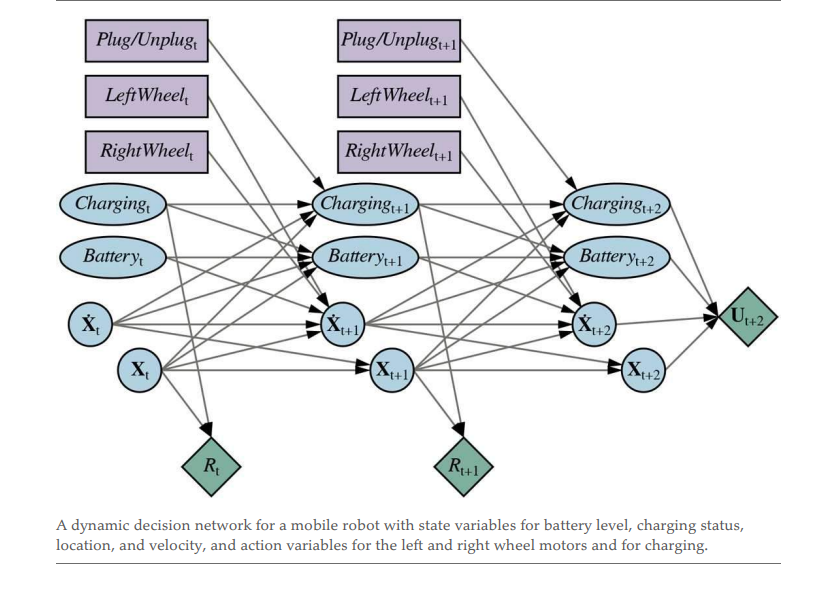
## What the Diagram Represents

The diagram is a **factored Markov Decision Process** unrolled over time.

Each vertical slice represents a time step:

- $t$
- $t+1$
- $t+2$

---

## State

At time $t$, the full state is composed of multiple variables:

$$
s_t = (Charging_t,\ Battery_t,\ X_t,\ \dot{X}_t)
$$

This is a **factored state representation** — the state is broken into components rather than treated as one large variable.

---

## Action

At time $t$, the agent chooses:

$$
a_t = (Plug_t,\ LeftWheel_t,\ RightWheel_t)
$$

These decisions influence the next state.

---

## State Transition

The next state is determined probabilistically by:

$$
P(s_{t+1} \mid s_t,\ a_t)
$$

This encodes the **Markov property**:

> The next state depends only on the current state and current action.

Arrows in the diagram represent these conditional dependencies.

---

## Reward

At each time step, the agent receives reward:

$$
R_t = R(s_t,\ a_t)
$$

---

## Utility Recursion

Total utility follows the Bellman recursion:

$$
U_t = R_t + \gamma \mathbb{E}[U_{t+1}]
$$

---

## Big Picture

The entire diagram reduces conceptually to:

$$
s_t \xrightarrow{a_t} s_{t+1}
$$

with reward at each step.

It is simply a structured graphical representation of:

State → Action → Next State → Reward → Repeat.
